In [365]:
import os
import re

import json
import pandas as pd
import matplotlib.pyplot as plt


In [366]:

path_foulder = "C:/Users/es25591/Workspace/CacheVideoPredict360/Results/" + "2026-02-23_15-05/"

pattern = re.compile(r"^debug_ep(\d+)\.json$")
records = []

for file_name in os.listdir(path_foulder):
    match = pattern.match(file_name)
    if not match:
        continue

    episode_index = int(match.group(1))
    file_path = os.path.join(path_foulder, file_name)

    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    if isinstance(data, dict):
        records.append({"episode_index": episode_index, **data})
    else:
        records.append({"episode_index": episode_index, "data": data})

records.sort(key=lambda x: x["episode_index"])
df = pd.DataFrame(records)


In [367]:
# Explore available columns and data types
print("Available columns in records:")
print(records[0].keys())
print("\nDataFrame columns:")
print(df.columns.tolist())
print("\nDataFrame dtypes:")
print(df.dtypes)

Available columns in records:
dict_keys(['episode_index', 'cache_hits', 'cache_misses', 'step_reward', 'cumulative_reward', 'base_action', 'base_layer_miss', 'enh_0_action', 'enh_1_action', 'enh_2_action', 'enh_3_action', 'enh_layer_missing_0', 'enh_layer_missing_1', 'enh_layer_missing_2', 'enh_layer_missing_3', 'train_loss_ctrl', 'epsilon_ctrl', 'train_loss', 'epsilon'])

DataFrame columns:
['episode_index', 'cache_hits', 'cache_misses', 'step_reward', 'cumulative_reward', 'base_action', 'base_layer_miss', 'enh_0_action', 'enh_1_action', 'enh_2_action', 'enh_3_action', 'enh_layer_missing_0', 'enh_layer_missing_1', 'enh_layer_missing_2', 'enh_layer_missing_3', 'train_loss_ctrl', 'epsilon_ctrl', 'train_loss', 'epsilon']

DataFrame dtypes:
episode_index           int64
cache_hits             object
cache_misses           object
step_reward            object
cumulative_reward      object
base_action            object
base_layer_miss        object
enh_0_action           object
enh_1_action

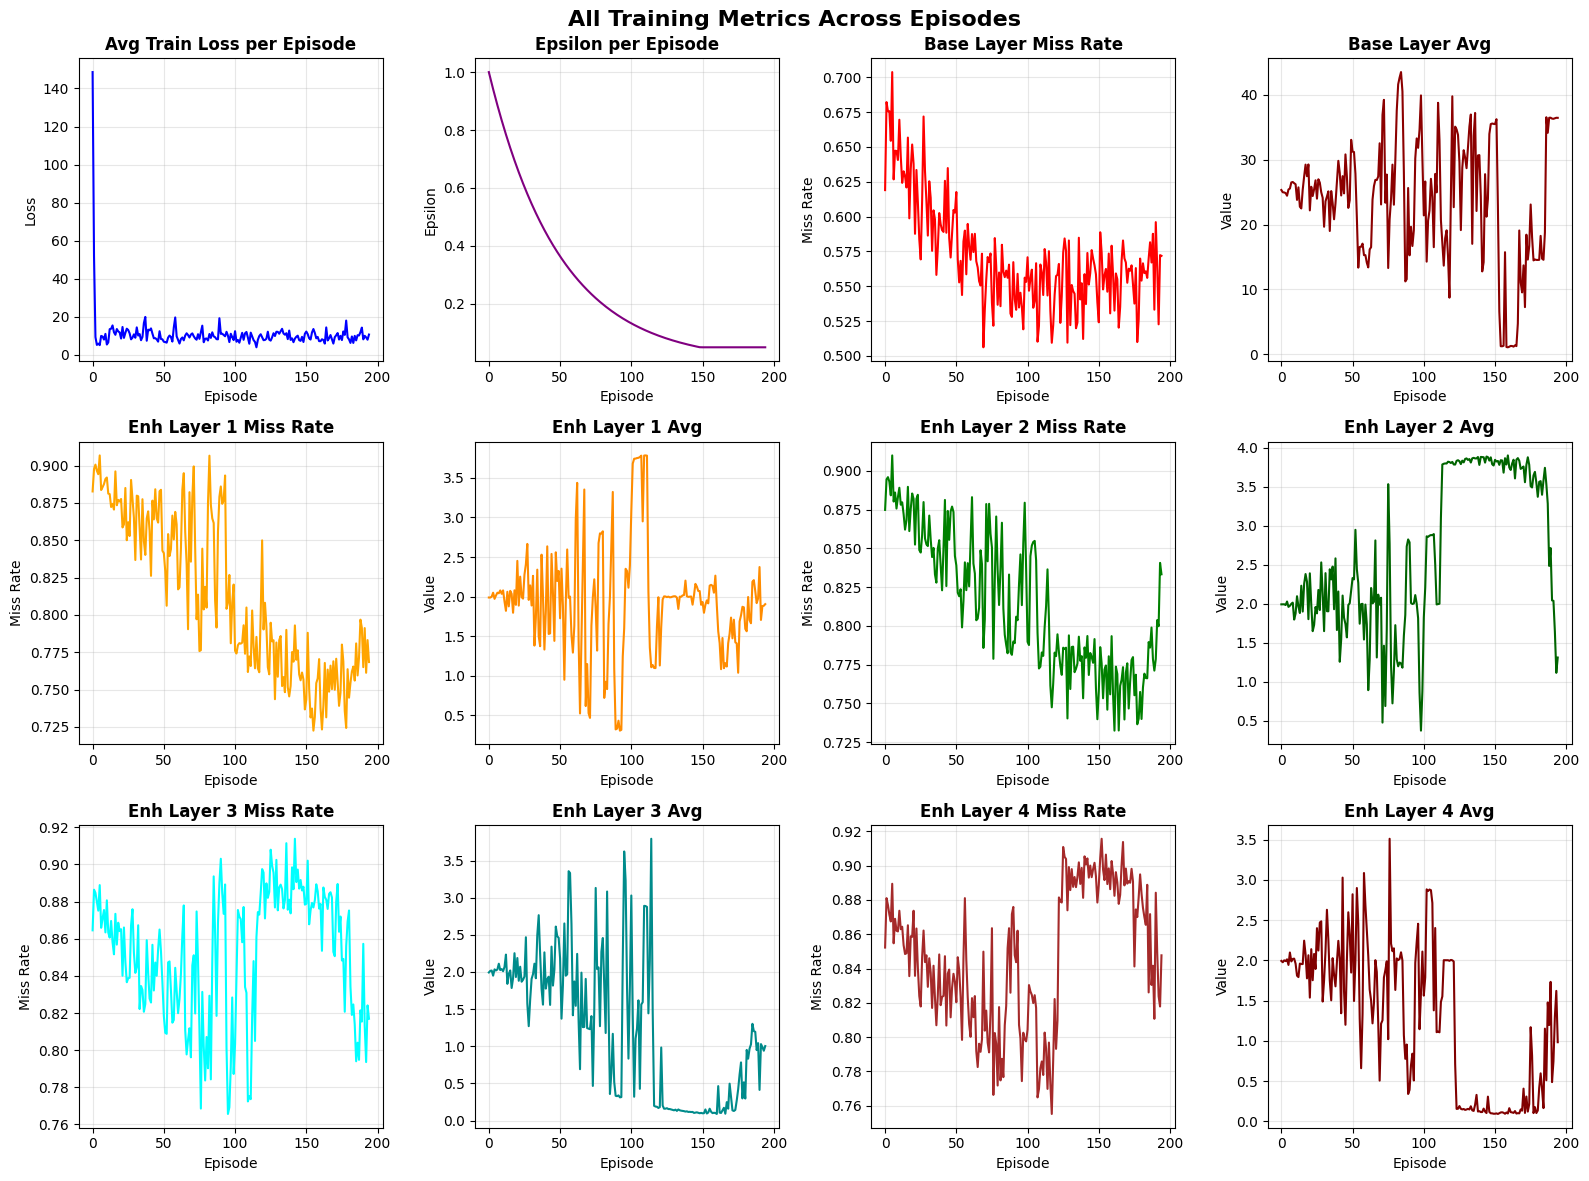

Total episodes: 195
Data contains metrics for: base layer + 4 enhancement layers


In [368]:
# Create comprehensive charts for all metrics
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('All Training Metrics Across Episodes', fontsize=16, fontweight='bold')

# Helper function to compute average from list columns
def get_avg_per_episode(col_name):
    return [sum(val)/len(val) if isinstance(val, list) else val 
            for val in df[col_name]]

episodes = df['episode_index'].values

# 1. Train Loss Average
ax = axes[0, 0]
avg_train_loss = get_avg_per_episode('train_loss')
ax.plot(episodes, avg_train_loss, color='blue', linewidth=1.5)
ax.set_title('Avg Train Loss per Episode', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Loss')
ax.grid(True, alpha=0.3)

# 2. Epsilon (exploration parameter)
ax = axes[0, 1]
avg_epsilon = get_avg_per_episode('epsilon')
ax.plot(episodes, avg_epsilon, color='purple', linewidth=1.5)
ax.set_title('Epsilon per Episode', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Epsilon')
ax.grid(True, alpha=0.3)

# 3. Base Layer Miss
ax = axes[0, 2]
avg_base_miss = get_avg_per_episode('base_layer_miss')
ax.plot(episodes, avg_base_miss, color='red', linewidth=1.5)
ax.set_title('Base Layer Miss Rate', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Miss Rate')
ax.grid(True, alpha=0.3)

# 4. Base Layer
ax = axes[0, 3]
avg_base = get_avg_per_episode('base_action')
ax.plot(episodes, avg_base, color='darkred', linewidth=1.5)
ax.set_title('Base Layer Avg', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)

# Enhancement Layer 1 - Miss and Value
ax = axes[1, 0]
avg_enh1_miss = get_avg_per_episode('enh_layer_missing_0')
ax.plot(episodes, avg_enh1_miss, color='orange', linewidth=1.5)
ax.set_title('Enh Layer 1 Miss Rate', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Miss Rate')
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
avg_enh1 = get_avg_per_episode('enh_0_action')
ax.plot(episodes, avg_enh1, color='darkorange', linewidth=1.5)
ax.set_title('Enh Layer 1 Avg', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)

# Enhancement Layer 2
ax = axes[1, 2]
avg_enh2_miss = get_avg_per_episode('enh_layer_missing_1')
ax.plot(episodes, avg_enh2_miss, color='green', linewidth=1.5)
ax.set_title('Enh Layer 2 Miss Rate', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Miss Rate')
ax.grid(True, alpha=0.3)

ax = axes[1, 3]
avg_enh2 = get_avg_per_episode('enh_1_action')
ax.plot(episodes, avg_enh2, color='darkgreen', linewidth=1.5)
ax.set_title('Enh Layer 2 Avg', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)

# Enhancement Layer 3
ax = axes[2, 0]
avg_enh3_miss = get_avg_per_episode('enh_layer_missing_2')
ax.plot(episodes, avg_enh3_miss, color='cyan', linewidth=1.5)
ax.set_title('Enh Layer 3 Miss Rate', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Miss Rate')
ax.grid(True, alpha=0.3)

ax = axes[2, 1]
avg_enh3 = get_avg_per_episode('enh_2_action')
ax.plot(episodes, avg_enh3, color='darkcyan', linewidth=1.5)
ax.set_title('Enh Layer 3 Avg', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)

# Enhancement Layer 4
ax = axes[2, 2]
avg_enh4_miss = get_avg_per_episode('enh_layer_missing_3')
ax.plot(episodes, avg_enh4_miss, color='brown', linewidth=1.5)
ax.set_title('Enh Layer 4 Miss Rate', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Miss Rate')
ax.grid(True, alpha=0.3)

ax = axes[2, 3]
avg_enh4 = get_avg_per_episode('enh_3_action')
ax.plot(episodes, avg_enh4, color='maroon', linewidth=1.5)
ax.set_title('Enh Layer 4 Avg', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total episodes: {len(episodes)}")
print(f"Data contains metrics for: base layer + 4 enhancement layers")

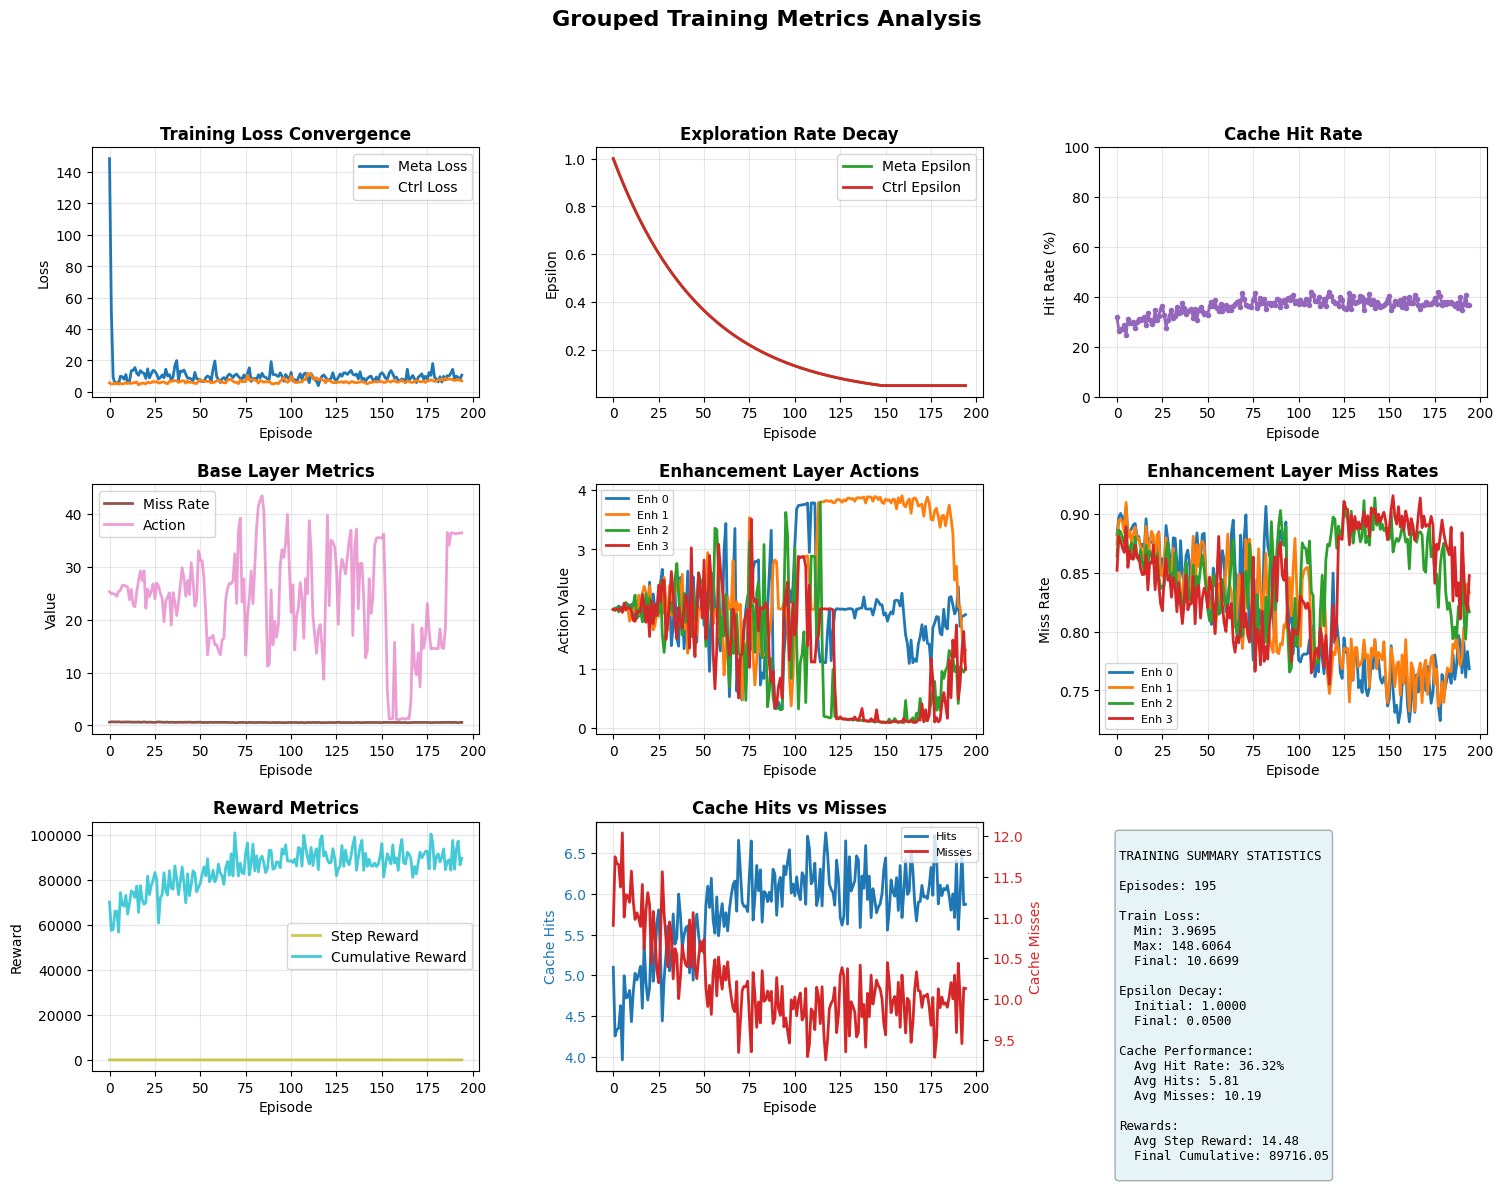

✓ Generated grouped analysis visualizations


In [369]:
# Group related metrics for focused analysis
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Training Convergence (Top-left)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(episodes, get_avg_per_episode('train_loss'), label='Meta Loss', color='#1f77b4', linewidth=2)
ax1.plot(episodes, get_avg_per_episode('train_loss_ctrl'), label='Ctrl Loss', color='#ff7f0e', linewidth=2)
ax1.set_title('Training Loss Convergence', fontweight='bold', fontsize=12)
ax1.set_xlabel('Episode')
ax1.set_ylabel('Loss')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# 2. Epsilon Decay (Top-middle)
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(episodes, get_avg_per_episode('epsilon'), label='Meta Epsilon', color='#2ca02c', linewidth=2)
ax2.plot(episodes, get_avg_per_episode('epsilon_ctrl'), label='Ctrl Epsilon', color='#d62728', linewidth=2)
ax2.set_title('Exploration Rate Decay', fontweight='bold', fontsize=12)
ax2.set_xlabel('Episode')
ax2.set_ylabel('Epsilon')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# 3. Cache Performance (Top-right)
ax3 = fig.add_subplot(gs[0, 2])
hits = get_avg_per_episode('cache_hits')
misses = get_avg_per_episode('cache_misses')
hit_rate = [h / (h + m + 1e-9) * 100 for h, m in zip(hits, misses)]
ax3.plot(episodes, hit_rate, color='#9467bd', linewidth=2, marker='o', markersize=3)
ax3.set_title('Cache Hit Rate', fontweight='bold', fontsize=12)
ax3.set_xlabel('Episode')
ax3.set_ylabel('Hit Rate (%)')
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, 100])

# 4. Base Layer Analysis (Middle-left)
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(episodes, get_avg_per_episode('base_layer_miss'), label='Miss Rate', color='#8c564b', linewidth=2)
ax4.plot(episodes, get_avg_per_episode('base_action'), label='Action', color='#e377c2', linewidth=2, alpha=0.7)
ax4.set_title('Base Layer Metrics', fontweight='bold', fontsize=12)
ax4.set_xlabel('Episode')
ax4.set_ylabel('Value')
ax4.legend(loc='best')
ax4.grid(True, alpha=0.3)

# 5. Enhancement Layer Actions (Middle-middle)
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(episodes, get_avg_per_episode('enh_0_action'), label='Enh 0', linewidth=2)
ax5.plot(episodes, get_avg_per_episode('enh_1_action'), label='Enh 1', linewidth=2)
ax5.plot(episodes, get_avg_per_episode('enh_2_action'), label='Enh 2', linewidth=2)
ax5.plot(episodes, get_avg_per_episode('enh_3_action'), label='Enh 3', linewidth=2)
ax5.set_title('Enhancement Layer Actions', fontweight='bold', fontsize=12)
ax5.set_xlabel('Episode')
ax5.set_ylabel('Action Value')
ax5.legend(loc='best', fontsize=8)
ax5.grid(True, alpha=0.3)

# 6. Enhancement Layer Miss Rates (Middle-right)
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(episodes, get_avg_per_episode('enh_layer_missing_0'), label='Enh 0', linewidth=2)
ax6.plot(episodes, get_avg_per_episode('enh_layer_missing_1'), label='Enh 1', linewidth=2)
ax6.plot(episodes, get_avg_per_episode('enh_layer_missing_2'), label='Enh 2', linewidth=2)
ax6.plot(episodes, get_avg_per_episode('enh_layer_missing_3'), label='Enh 3', linewidth=2)
ax6.set_title('Enhancement Layer Miss Rates', fontweight='bold', fontsize=12)
ax6.set_xlabel('Episode')
ax6.set_ylabel('Miss Rate')
ax6.legend(loc='best', fontsize=8)
ax6.grid(True, alpha=0.3)

# 7. Reward Metrics (Bottom-left)
ax7 = fig.add_subplot(gs[2, 0])
ax7.plot(episodes, get_avg_per_episode('step_reward'), label='Step Reward', color='#bcbd22', linewidth=2, alpha=0.8)
ax7.plot(episodes, get_avg_per_episode('cumulative_reward'), label='Cumulative Reward', color='#17becf', linewidth=2, alpha=0.8)
ax7.set_title('Reward Metrics', fontweight='bold', fontsize=12)
ax7.set_xlabel('Episode')
ax7.set_ylabel('Reward')
ax7.legend(loc='best')
ax7.grid(True, alpha=0.3)

# 8. Cache Hits vs Misses (Bottom-middle)
ax8 = fig.add_subplot(gs[2, 1])
ax8_twin = ax8.twinx()
line1 = ax8.plot(episodes, hits, label='Hits', color='#1f77b4', linewidth=2)
line2 = ax8_twin.plot(episodes, misses, label='Misses', color='#d62728', linewidth=2)
ax8.set_title('Cache Hits vs Misses', fontweight='bold', fontsize=12)
ax8.set_xlabel('Episode')
ax8.set_ylabel('Cache Hits', color='#1f77b4')
ax8_twin.set_ylabel('Cache Misses', color='#d62728')
ax8.tick_params(axis='y', labelcolor='#1f77b4')
ax8_twin.tick_params(axis='y', labelcolor='#d62728')
ax8.grid(True, alpha=0.3)
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax8.legend(lines, labels, loc='upper right', fontsize=8)

# 9. Episode Summary Statistics (Bottom-right)
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

# Create summary statistics text
stats_text = f"""
TRAINING SUMMARY STATISTICS

Episodes: {len(episodes)}

Train Loss:
  Min: {min(get_avg_per_episode('train_loss')):.4f}
  Max: {max(get_avg_per_episode('train_loss')):.4f}
  Final: {get_avg_per_episode('train_loss')[-1]:.4f}

Epsilon Decay:
  Initial: {get_avg_per_episode('epsilon')[0]:.4f}
  Final: {get_avg_per_episode('epsilon')[-1]:.4f}

Cache Performance:
  Avg Hit Rate: {sum(hit_rate)/len(hit_rate):.2f}%
  Avg Hits: {sum(hits)/len(hits):.2f}
  Avg Misses: {sum(misses)/len(misses):.2f}

Rewards:
  Avg Step Reward: {sum(get_avg_per_episode('step_reward'))/len(episodes):.2f}
  Final Cumulative: {get_avg_per_episode('cumulative_reward')[-1]:.2f}
"""

ax9.text(0.05, 0.95, stats_text, transform=ax9.transAxes, 
         fontsize=9, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

fig.suptitle('Grouped Training Metrics Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("✓ Generated grouped analysis visualizations")

C:\Users\es25591\AppData\Local\Temp\ipykernel_11296\1260820453.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(enh_actions, labels=['Enh 0', 'Enh 1', 'Enh 2', 'Enh 3'], patch_artist=True)
C:\Users\es25591\AppData\Local\Temp\ipykernel_11296\1260820453.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(enh_missing, labels=['Enh 0', 'Enh 1', 'Enh 2', 'Enh 3'], patch_artist=True)


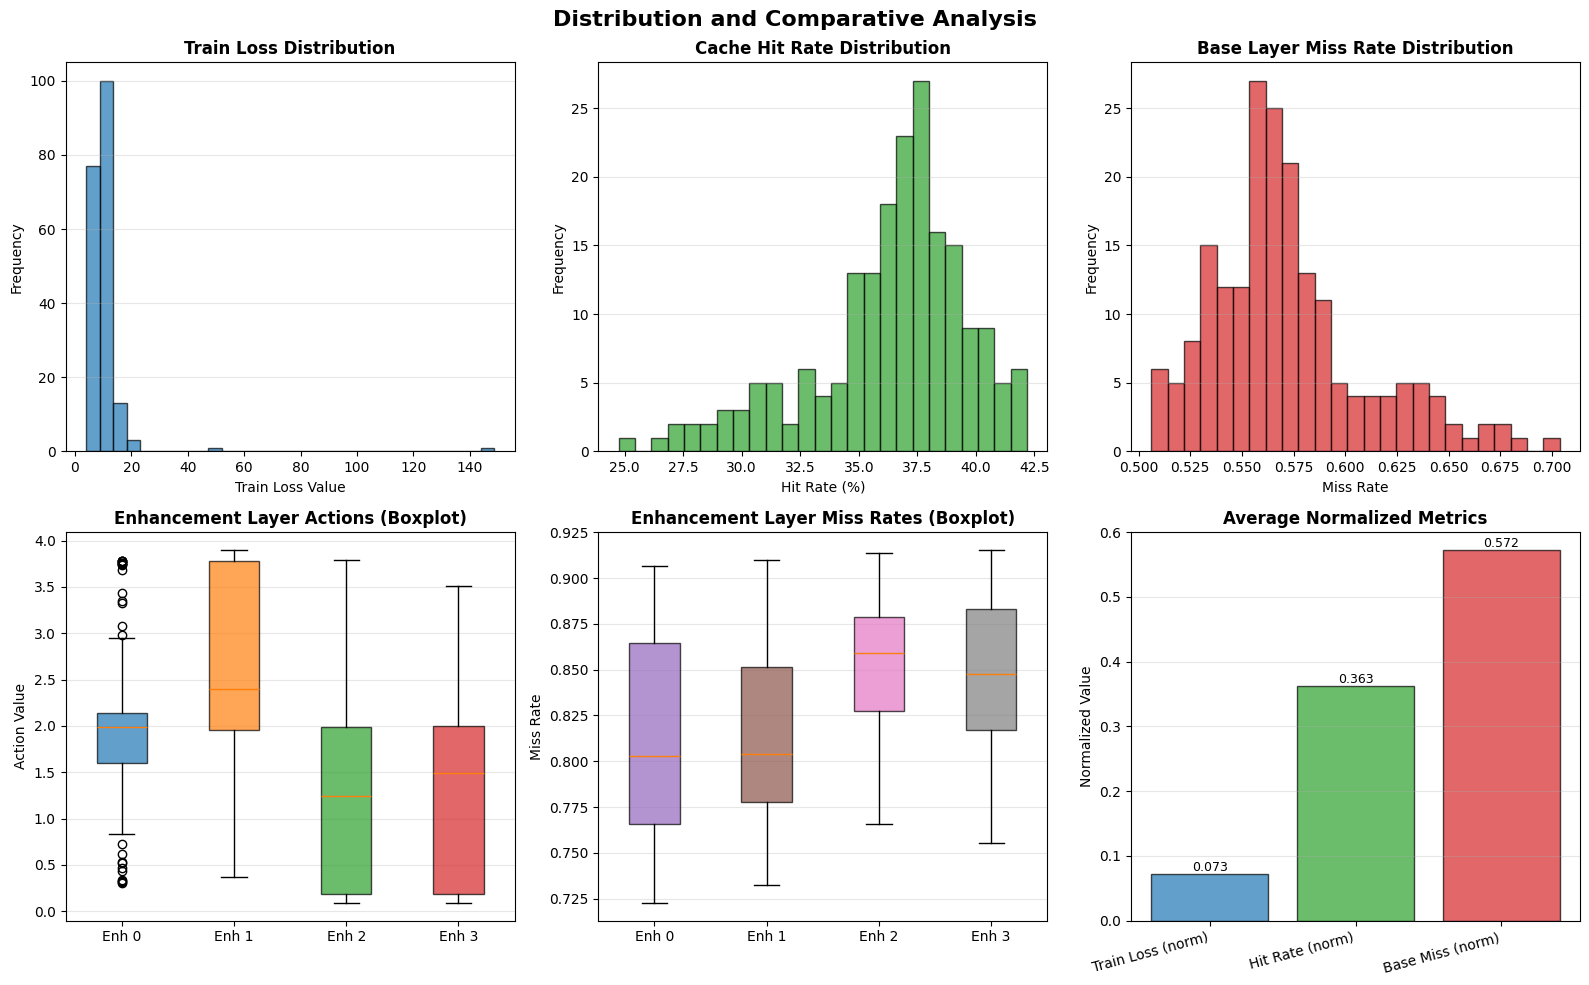


COMPARATIVE METRICS ANALYSIS

Train Loss Statistics:
  Mean: 10.7778
  Std:  10.6754

Cache Hit Rate Statistics:
  Mean: 36.32%
  Std:  3.31%

Base Layer Miss Rate Statistics:
  Mean: 0.5719
  Std:  0.0375

Enhancement Layer Actions Summary:
  Enh 0 - Mean: 1.9433, Range: [0.31, 3.78]
  Enh 1 - Mean: 2.6591, Range: [0.37, 3.90]
  Enh 2 - Mean: 1.2301, Range: [0.09, 3.79]
  Enh 3 - Mean: 1.2892, Range: [0.09, 3.51]

Enhancement Layer Missing Summary:
  Enh 0 - Mean: 0.8129, Range: [0.7226, 0.9068]
  Enh 1 - Mean: 0.8136, Range: [0.7324, 0.9099]
  Enh 2 - Mean: 0.8522, Range: [0.7656, 0.9138]
  Enh 3 - Mean: 0.8471, Range: [0.7552, 0.9156]



In [370]:
# Distribution and comparative analysis
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution and Comparative Analysis', fontsize=16, fontweight='bold')

# 1. Train Loss Distribution (Histogram)
ax = axes[0, 0]
train_loss_data = get_avg_per_episode('train_loss')
ax.hist(train_loss_data, bins=30, color='#1f77b4', alpha=0.7, edgecolor='black')
ax.set_title('Train Loss Distribution', fontweight='bold')
ax.set_xlabel('Train Loss Value')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3, axis='y')

# 2. Cache Performance Distribution
ax = axes[0, 1]
hit_rate_data = [h / (h + m + 1e-9) * 100 for h, m in zip(hits, misses)]
ax.hist(hit_rate_data, bins=25, color='#2ca02c', alpha=0.7, edgecolor='black')
ax.set_title('Cache Hit Rate Distribution', fontweight='bold')
ax.set_xlabel('Hit Rate (%)')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3, axis='y')

# 3. Base Layer Miss Rate Distribution
ax = axes[0, 2]
base_miss_data = get_avg_per_episode('base_layer_miss')
ax.hist(base_miss_data, bins=25, color='#d62728', alpha=0.7, edgecolor='black')
ax.set_title('Base Layer Miss Rate Distribution', fontweight='bold')
ax.set_xlabel('Miss Rate')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3, axis='y')

# 4. Enhancement Layer Actions Comparison (Boxplot)
ax = axes[1, 0]
enh_actions = [
    get_avg_per_episode('enh_0_action'),
    get_avg_per_episode('enh_1_action'),
    get_avg_per_episode('enh_2_action'),
    get_avg_per_episode('enh_3_action')
]
bp = ax.boxplot(enh_actions, labels=['Enh 0', 'Enh 1', 'Enh 2', 'Enh 3'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Enhancement Layer Actions (Boxplot)', fontweight='bold')
ax.set_ylabel('Action Value')
ax.grid(True, alpha=0.3, axis='y')

# 5. Enhancement Layer Missing Comparison (Boxplot)
ax = axes[1, 1]
enh_missing = [
    get_avg_per_episode('enh_layer_missing_0'),
    get_avg_per_episode('enh_layer_missing_1'),
    get_avg_per_episode('enh_layer_missing_2'),
    get_avg_per_episode('enh_layer_missing_3')
]
bp = ax.boxplot(enh_missing, labels=['Enh 0', 'Enh 1', 'Enh 2', 'Enh 3'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#9467bd', '#8c564b', '#e377c2', '#7f7f7f']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Enhancement Layer Miss Rates (Boxplot)', fontweight='bold')
ax.set_ylabel('Miss Rate')
ax.grid(True, alpha=0.3, axis='y')

# 6. Normalized Metrics Comparison
ax = axes[1, 2]
metrics_to_compare = {
    'Train Loss (norm)': [v / (max(train_loss_data) or 1) for v in train_loss_data],
    'Hit Rate (norm)': [v / 100 for v in hit_rate_data],
    'Base Miss (norm)': [v for v in base_miss_data],
}
# Plot means as a bar chart
means = {k: sum(v) / len(v) for k, v in metrics_to_compare.items()}
colors_bar = ['#1f77b4', '#2ca02c', '#d62728']
bars = ax.bar(range(len(means)), list(means.values()), color=colors_bar, alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(means)))
ax.set_xticklabels(list(means.keys()), rotation=15, ha='right')
ax.set_title('Average Normalized Metrics', fontweight='bold')
ax.set_ylabel('Normalized Value')
ax.grid(True, alpha=0.3, axis='y')

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print comparative statistics
print("\n" + "="*70)
print("COMPARATIVE METRICS ANALYSIS")
print("="*70)
print(f"\nTrain Loss Statistics:")
print(f"  Mean: {sum(train_loss_data)/len(train_loss_data):.4f}")
print(f"  Std:  {(sum((x - sum(train_loss_data)/len(train_loss_data))**2 for x in train_loss_data) / len(train_loss_data))**0.5:.4f}")

print(f"\nCache Hit Rate Statistics:")
print(f"  Mean: {sum(hit_rate_data)/len(hit_rate_data):.2f}%")
print(f"  Std:  {(sum((x - sum(hit_rate_data)/len(hit_rate_data))**2 for x in hit_rate_data) / len(hit_rate_data))**0.5:.2f}%")

print(f"\nBase Layer Miss Rate Statistics:")
print(f"  Mean: {sum(base_miss_data)/len(base_miss_data):.4f}")
print(f"  Std:  {(sum((x - sum(base_miss_data)/len(base_miss_data))**2 for x in base_miss_data) / len(base_miss_data))**0.5:.4f}")

print(f"\nEnhancement Layer Actions Summary:")
for i, enh in enumerate(enh_actions):
    mean_val = sum(enh) / len(enh)
    print(f"  Enh {i} - Mean: {mean_val:.4f}, Range: [{min(enh):.2f}, {max(enh):.2f}]")

print(f"\nEnhancement Layer Missing Summary:")
for i, enh in enumerate(enh_missing):
    mean_val = sum(enh) / len(enh)
    print(f"  Enh {i} - Mean: {mean_val:.4f}, Range: [{min(enh):.4f}, {max(enh):.4f}]")
print("="*70 + "\n")